# Feature Engineering V

**Upsampling FRED data to weekly.**

Author: Pete King

Here we approach the mixed-frequency FRED data from a different angle.  After investigating several options, a weekly frequency strikes a good balance between ease of implementation and business case (forecasting a near-term outlook with accuracy).


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
from fredapi import Fred

import data_prep as dp

DOWNSAMPLE_FOLDER = 'data/downsample/'

## I. Import FRED Data

This section is a copy from Tom's original notebook.

In [2]:
# Need an API key to access the FRED data
api_key = input("Enter your FRED API key: ")
fred = Fred(api_key=api_key)
print("Successfully connected to FRED API!")

Enter your FRED API key:  2e82bb1954b91cb0f75d7d8ca5397d30


Successfully connected to FRED API!


In [3]:
fred_data = dp.get_fred_data(fred)

## II. Compute stationary features

These computations are based on Tom's notebooks -- see those for rationale of first differencing for yields and percent change for macroeconomic and other data.

### First Difference (yields)

Yields come as daily values, so we need to downsample these to weekly.  We compute a first difference (i.e., "delta" yield) over the time period.

In [4]:
# Yield Columns
yield_cols = [
    'one_month_yield', 'three_month_yield', 'six_month_yield',
    'one_year_yield', 'two_year_yield', 'five_year_yield',
    'ten_year_yield', 'thirty_year_yield'
]

In [5]:
fred_transformed = {}
for series_name in yield_cols:
    fred_transformed[series_name + '_diff'] = fred_data[series_name].resample(
        'W', closed='right', label='right'
    ).pipe(lambda x: x.last() - x.first())

### Percentage Change

From Tom's notebook, we compute percentage change for these columns.

We will then upsample the quarterly and monthly columns to a weekly frequency, using a forward fill for missing values.

In [6]:
# Columns to apply percentage change transformation
quarterly = [
    'nominal_GDP', 'real_GDP', 'debt_to_GDP', 'debt_interest',
    'consumer_price_index', 'core_PCI', 'personal_consumption_expenditure',
    'core_PCE', 'producer_price_index',
]
monthly = [
    'unemployment_rate',
    'teenager_unemployment_rate', 'adult_unemployment_rate',
    'male_unemployment_rate', 'female_unemployment_rate',
    'average_duration_of_unemployment'
]
weekly = [
    'initial_jobless_claims',
    'continued_jobless_claims'
]
pct_chg_cols = quarterly + monthly + weekly

In [7]:
for series_name in pct_chg_cols:
    fred_transformed[series_name + '_chg'] = fred_data[series_name].pct_change(
    ).resample('W', closed='right', label='right').ffill()

## III. Merge transformed data

With raw data now transformed and resampled to weekly values (all labels assigned to the final Sunday of each week), we merge the transformed data into a combined weekly dataframe.

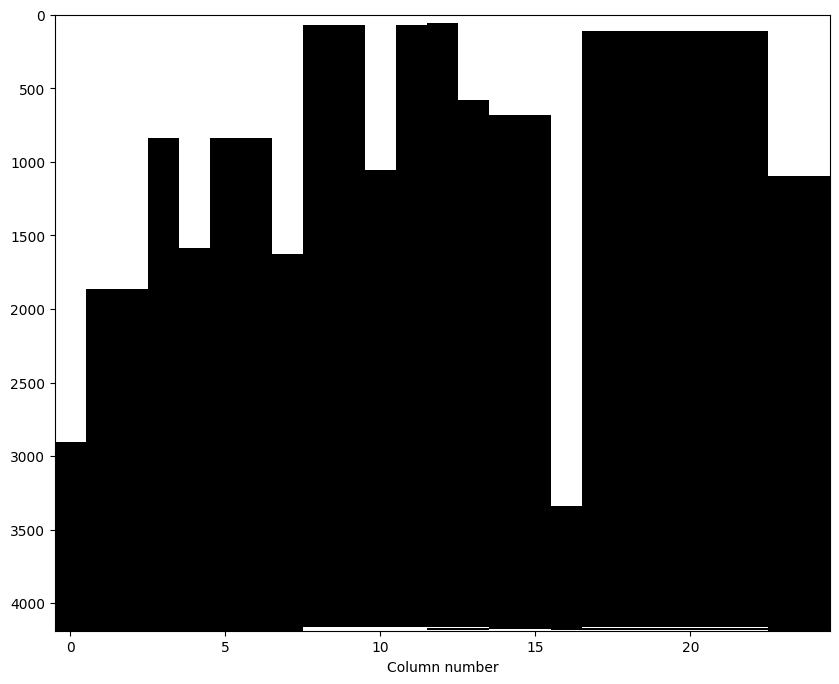

In [8]:
fred_df = pd.DataFrame(
    {name: series for name, series in fred_transformed.items()}
)
dp.view_nan(fred_df);

We need to be a little careful with the tail end of the series, since we can see we have some missing values.  A little investigation reveals that the last quarterly value for GDP was from Oct 2025.  We want to forward fill the tail of our data, but we should ensure that we stop on 31 Dec 2025.

In [9]:
# Get starting date for the weekly index
start_date = {}
for name, series in fred_transformed.items():
    start_date[name] = fred_transformed[name].dropna().index[0]
start_dates = sorted(
    [(name, date) for name, date in start_date.items()],
    key=lambda x:x[1]
)
start_dates[0]

('consumer_price_index_chg', Timestamp('1947-02-02 00:00:00'))

In [10]:
# Get last common final date for the weekly day index
final_date = {}
for name, series in fred_transformed.items():
    final_date[name] = fred_transformed[name].dropna().index[-1]
last_dates = sorted(
    [(name, date) for name, date in final_date.items()],
    key=lambda x:x[1]
)
last_dates[0]

('nominal_GDP_chg', Timestamp('2025-10-05 00:00:00'))

### Create empty DataFrame with weekly index

In [11]:
# Create the weekly index as a Pandas Series object
sundays = pd.date_range(
    start=start_dates[0][1],
    end=pd.Timestamp('2025-12-31'),
    freq='W'
)
sundays

DatetimeIndex(['1947-02-02', '1947-02-09', '1947-02-16', '1947-02-23',
               '1947-03-02', '1947-03-09', '1947-03-16', '1947-03-23',
               '1947-03-30', '1947-04-06',
               ...
               '2025-10-26', '2025-11-02', '2025-11-09', '2025-11-16',
               '2025-11-23', '2025-11-30', '2025-12-07', '2025-12-14',
               '2025-12-21', '2025-12-28'],
              dtype='datetime64[us]', length=4118, freq='W-SUN')

In [12]:
# Create an empty DataFrame with a weekly index for the desired time period
sundays_df = pd.DataFrame({}, index=sundays)

### Merge weekly time series

In [13]:
# Forward fill the FRED DataFrame, then left join to end by 31 Dec 2025
fred_final_df = pd.merge(
    left=sundays_df,
    right=fred_df.ffill(),
    how='inner',
    left_index=True,
    right_index=True
)
fred_final_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,core_PCE_chg,producer_price_index_chg,unemployment_rate_chg,teenager_unemployment_rate_chg,adult_unemployment_rate_chg,male_unemployment_rate_chg,female_unemployment_rate_chg,average_duration_of_unemployment_chg,initial_jobless_claims_chg,continued_jobless_claims_chg
1947-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-02-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-02-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,0.02,-0.03,-0.02,0.00,0.01,-0.02,-0.02,-0.01,0.011076,0.001628,...,0.001792,0.002526,0.023256,-0.043165,0.00000,0.000000,0.023256,-0.016327,-0.009174,-0.019669
2025-12-07,-0.16,-0.10,-0.07,-0.01,0.02,0.05,0.05,0.05,0.011076,0.001628,...,0.003577,0.003806,-0.022222,-0.036810,-0.04878,-0.022222,-0.022222,0.056277,0.087963,-0.003696
2025-12-14,-0.06,-0.10,-0.11,-0.07,-0.05,0.00,0.02,0.04,0.011076,0.001628,...,0.003577,0.003806,-0.022222,-0.036810,-0.04878,-0.022222,-0.022222,0.056277,-0.046809,0.012189
2025-12-21,-0.06,-0.03,0.00,-0.01,-0.03,-0.03,-0.02,-0.02,0.011076,0.001628,...,0.003577,0.003806,-0.022222,-0.036810,-0.04878,-0.022222,-0.022222,0.056277,-0.040179,-0.026178


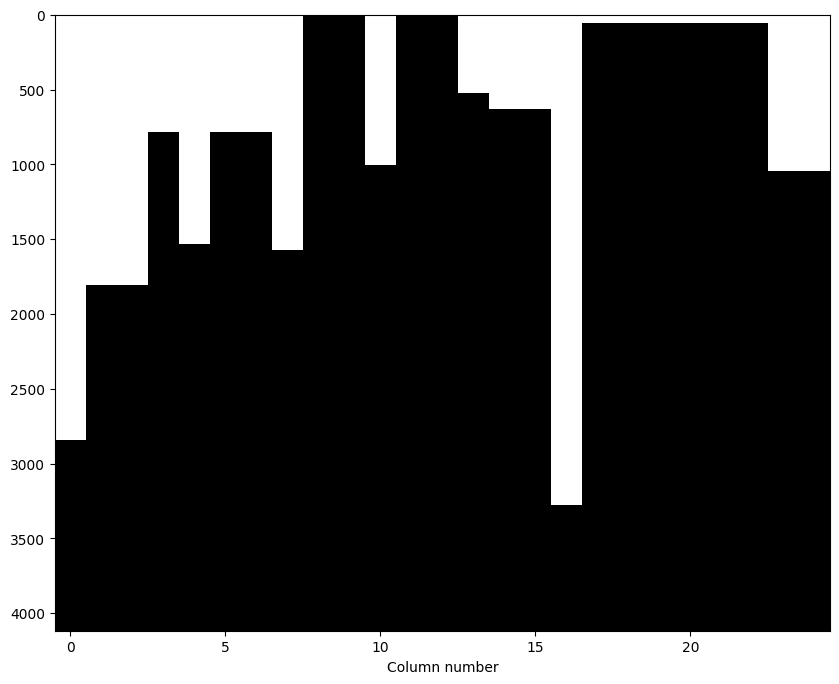

In [14]:
dp.view_nan(fred_final_df);

We now have a weekly DataFrame filled with transformed macroeconomic and other market index data.

In [15]:
fred_final_df.to_csv(
    f'{DOWNSAMPLE_FOLDER}W/fred_downsample.csv', index_label='date'
)